In [23]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [16]:
# Load dataset
df = pd.read_csv("BostonHousing.csv")

df.head()

,crim,zn,indus,chas,nox,rm,age,dis,rad,tax,ptratio,b,lstat,medv
0,0.00632,18.0,2.31,0,0.538,6.575,65.2,4.0900,1,296,15.3,396.90,4.98,24.0
1,0.02731,0.0,7.07,0,0.469,6.421,78.9,4.9671,2,242,17.8,396.90,9.14,21.6
2,0.02729,0.0,7.07,0,0.469,7.185,61.1,4.9671,2,242,17.8,392.83,4.03,34.7
3,0.03237,0.0,2.18,0,0.458,6.998,45.8,6.0622,3,222,18.7,394.63,2.94,33.4
4,0.06905,0.0,2.18,0,0.458,7.147,54.2,6.0622,3,222,18.7,396.90,5.33,36.2


In [17]:
print(df.columns)

Index(['crim', 'zn', 'indus', 'chas', 'nox', 'rm', 'age', 'dis', 'rad', 'tax',
       'ptratio', 'b', 'lstat', 'medv'],
      dtype='object')


In [18]:
# Features and Target
X = df.drop("medv", axis=1)     
y = df["medv"]                   

In [10]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [19]:
models = {
    "Linear Regression": LinearRegression(),
    "Decision Tree": DecisionTreeRegressor(random_state=42),
    "Random Forest": RandomForestRegressor(random_state=42)
}

In [20]:
results = []

for name, model in models.items():

    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)

    mae = mean_absolute_error(y_test, y_pred)
    mse = mean_squared_error(y_test, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_test, y_pred)

    results.append([name, mae, mse, rmse, r2])

results_df = pd.DataFrame(
    results,
    columns=["Model", "MAE", "MSE", "RMSE", "R2 Score"]
)

print(results_df)

               Model       MAE        MSE      RMSE  R2 Score
0  Linear Regression  3.189092  24.291119  4.928602  0.668759
1      Decision Tree  2.394118  10.416078  3.227395  0.857963
2      Random Forest  2.039539   7.901514  2.810963  0.892253


In [21]:
best_model = results_df.loc[results_df["R2 Score"].idxmax()]

print("\nBest Model:")
print(best_model)


Best Model:
Model       Random Forest
MAE              2.039539
MSE              7.901514
RMSE             2.810963
R2 Score         0.892253
Name: 2, dtype: object


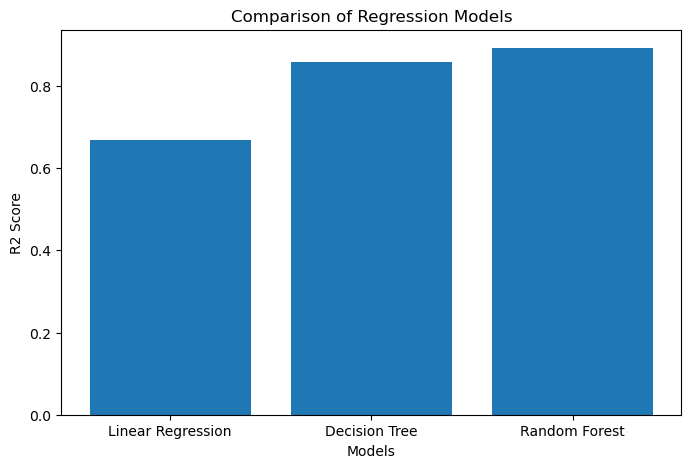

In [24]:
plt.figure(figsize=(8,5))
plt.bar(results_df["Model"], results_df["R2 Score"])

plt.title("Comparison of Regression Models")
plt.xlabel("Models")
plt.ylabel("R2 Score")

plt.show()

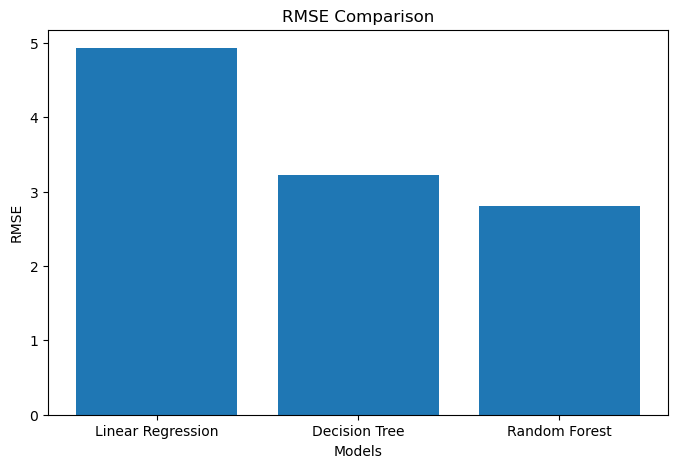

In [27]:
plt.figure(figsize=(8,5))
plt.bar(results_df["Model"], results_df["RMSE"])

plt.title("RMSE Comparison")
plt.xlabel("Models")
plt.ylabel("RMSE")

plt.show()

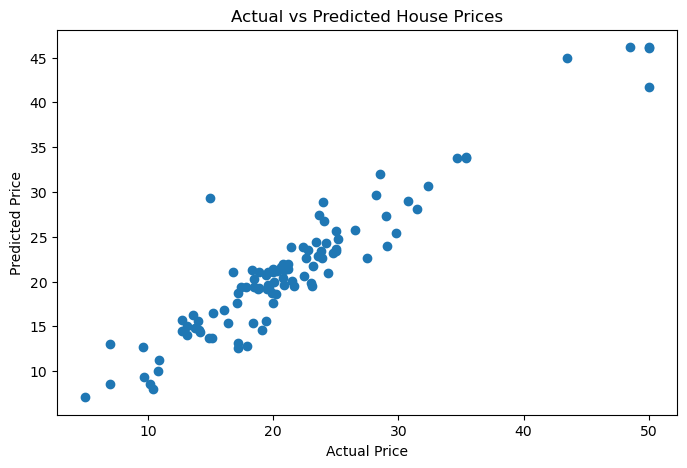

In [28]:
best_model = RandomForestRegressor(random_state=42)
best_model.fit(X_train, y_train)

y_pred = best_model.predict(X_test)

plt.figure(figsize=(8,5))
plt.scatter(y_test, y_pred)

plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Actual vs Predicted House Prices")

plt.show()

In [29]:
prediction = pd.DataFrame({
    "Actual Price": y_test,
    "Predicted Price": y_pred
})

print(prediction.head(10))

     Actual Price  Predicted Price
173          23.6           22.839
274          32.4           30.676
491          13.6           16.317
72           22.8           23.510
452          16.1           16.819
76           20.0           21.374
316          17.8           19.358
140          14.0           15.620
471          19.6           21.091
500          16.8           21.073
